# AI in Healthcare: Predicting Breast Cancer Patient Outcomes from Registry Data

**What this notebook does.** It builds a small, validated *predictive-analytics* application on real cancer-registry data. It takes a patient's clinical and tumor characteristics and estimates the probability that the patient is recorded as deceased by the end of the registry follow-up. It then flags higher-risk patients using a threshold chosen on training data only.


**How it maps to the assignment**

| Requirement | Where it is addressed |
|---|---|
| Choose a recent AI-driven healthcare innovation and research it | Section 1 (Clairity Breast, an FDA-authorized AI breast cancer risk tool) |
| Create a simple AI-driven application | Sections 3-10 (model) and Section 11 (`predict_risk()` function, plus a Streamlit app in `app.py`) |
| Comments in the code | Every code cell explains *why* a step is done, not just what it does |
| Data-centric and ethical considerations | Sections 2, 4, 9, 12 (data quality, leakage, calibration, subgroup audit, limitations) |

**Development note.** This project was developed with assistance from Google Gemini and Claude for design, code review, and documentation, as the assignment permits. All numbers shown come from running this notebook end to end.

**AI in the loop: possible extension**

The assignment aid suggests NLP for symptom text. That does not fit tabular registry data, so it is intentionally left out. A realistic future extension would use NLP to pull the structured fields used here (tumor size, node counts, grade) out of free-text pathology reports.

Full references are listed in Section 13.

## 1. Research: the innovation and why it matters

### The innovation: Clairity Breast (AI breast cancer risk prediction)

In June 2025 the U.S. FDA granted *De Novo* authorization to **Clairity Breast**, described in coverage as the first AI platform authorized to predict a woman's **five-year risk of developing breast cancer** from an ordinary screening mammogram alone. Key facts from public reporting:

* **What it does differently.** Traditional risk calculators (for example Gail and Tyrer-Cuzick) rely on questionnaire-style inputs such as family history and reproductive history. Clairity Breast instead analyzes subtle patterns in the mammogram image itself and outputs a five-year risk percentage. It is a separate risk score, not part of the radiologist's image interpretation.
* **Evidence and validation (as reported).** Coverage of the FDA decision cites validation on more than 77,000 mammograms from five screening centers. The company reports training on more than 1.7 million mammograms and external validation on over 122,000 exams across 10 U.S. health systems. Note that much of this is company-reported; independent, peer-reviewed confirmation is what clinicians will look for.
* **Real-world rollout.** The first clinical patient received a score in February 2026, and a clinic in Massachusetts began offering it to routine mammogram patients. In 2026 the NCCN breast cancer screening guidelines added the tool, using a five-year risk of at least 1.7% as one criterion for identifying higher-risk patients, which can lead to supplemental imaging or risk-reduction strategies.

### Why it is a good anchor for this project

Clairity Breast is an example of **predictive analytics in healthcare**: routine data goes in, an individual risk estimate comes out, and a *threshold* turns that estimate into an action (extra imaging, closer follow-up). Building even a small version of this workflow forces the same design questions that regulators and clinicians ask of the real product:

1. Is the prediction based only on information that would be available at decision time? (**leakage**)
2. Does a 90% accuracy figure mean anything when only a small share of patients have the outcome? (**class imbalance, PR-AUC**)
3. Are the predicted probabilities trustworthy? (**calibration**)
4. Who does the model work well for, and who does it fail? (**subgroup performance, bias**)
5. Where should the action threshold sit, and who bears the cost of missed cases versus false alarms? (**threshold selection**)

### How this project differs (honest scope)

Clairity works on **images** for people **without** a cancer diagnosis and predicts **future incidence**. This project uses **tabular registry data** on women **already diagnosed** and predicts a **prognosis outcome** (vital status). It is an educational analog of the risk-scoring workflow, not a replica of the product and not a clinical tool.

### Data source

* **Dataset:** SEER breast cancer data (Kaggle: `reihanenamdari/breast-cancer`), derived from the November 2017 update of the U.S. National Cancer Institute's SEER Program. According to the dataset description, it covers female patients with infiltrating duct and lobular carcinoma diagnosed 2006-2010, after excluding patients with unknown tumor size or lymph node counts and those with under one month of survival, leaving **4,024 patients**.
* Data is de-identified registry data intended for research.

## 2. Problem definition and design decisions

**Task.** Binary classification: given diagnosis-time characteristics, predict `Dead` (1) versus `Alive` (0) at the end of registry follow-up.

**Important caveats about the label**

* `status` is *vital status at last follow-up*, not "died within five years". An "Alive" patient with short follow-up is not a confirmed survivor (**censoring**), and "Dead" includes deaths from any cause.
* The positive class is a minority (about 15% of patients), so plain accuracy is misleading.

**Design decisions made in this revision (and why)**

| Decision | Reason |
|---|---|
| **Drop `survival_months` from the features** | It is only known after the outcome occurs. Using it to predict `status` is *data leakage* and produces unrealistically strong results (demonstrated in Section 6). |
| **Ordinal encoding for stage and differentiation** | T stage, N stage, AJCC 6th stage and tumor differentiation have a natural order that one-hot encoding throws away. |
| **Drop `grade`** | It duplicates `differentiate` (verified with a cross-tab in Section 3). |
| **Exclude `race` from the model inputs** | Race is kept only to *audit* subgroup performance. This is switchable with `USE_RACE_AS_FEATURE`. |
| **Everything inside one sklearn `Pipeline`** | Encoders and scalers are re-fit inside each cross-validation fold, so no information leaks from validation folds. |
| **Compare models with cross-validation on the training set** | The test set is used once, at the end. |
| **Choose the decision threshold on out-of-fold training predictions** | The default 0.5 cutoff is a poor fit for an imbalanced outcome where missing a high-risk patient is costly. |

## 3. Setup, data loading, and data quality checks

In [1]:
# --- Imports -----------------------------------------------------------------
import json
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn
from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, average_precision_score, brier_score_loss,
                             confusion_matrix, f1_score, make_scorer, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_val_score, cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# --- Experiment configuration (all tunable choices live in one place) --------
RANDOM_STATE = 42          # makes splits, CV folds and models reproducible
TEST_SIZE = 0.20           # share of patients held out for the final, one-time evaluation
TARGET_RECALL = 0.80       # clinical goal: catch at least ~80% of patients who died
USE_RACE_AS_FEATURE = False  # False = race is used only for the fairness audit, not as a model input

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)  # trained model + metadata are saved here for the app

print(f"scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

scikit-learn 1.6.1 | pandas 2.2.3


In [2]:
# --- Load the data -------------------------------------------------------------
# Option 1: a local copy at data/Breast_Cancer.csv (fastest, works offline).
# Option 2: download from Kaggle with kagglehub (needs internet; first run may ask for Kaggle login).
LOCAL_CSV = Path("data/Breast_Cancer.csv")
KAGGLE_HANDLE = "reihanenamdari/breast-cancer"
KAGGLE_FILE = "Breast_Cancer.csv"

if LOCAL_CSV.exists():
    df_raw = pd.read_csv(LOCAL_CSV)
    data_source = f"local file {LOCAL_CSV}"
else:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter
    df_raw = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, KAGGLE_HANDLE, KAGGLE_FILE)
    data_source = f"Kaggle dataset {KAGGLE_HANDLE}"

print(f"Loaded from {data_source}: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
display(df_raw.head())

Using Colab cache for faster access to the 'breast-cancer' dataset.
Loaded from Kaggle dataset reihanenamdari/breast-cancer: 4,024 rows x 16 columns


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [3]:
# --- Clean column names and text values ---------------------------------------
df = df_raw.copy()

# Standardize names: trim, lowercase, spaces -> underscores. Some raw names have trailing spaces
# (e.g. "T Stage "), which would otherwise cause silent KeyErrors later.
df.columns = df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)

# The source file misspells "regional" as "reginol"; fix it so names read clearly.
df = df.rename(columns={"reginol_node_positive": "regional_node_positive"})

# Trim stray whitespace inside text values (e.g. " anaplastic; Grade IV").
text_cols = df.select_dtypes(exclude="number").columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

expected = {"age", "race", "marital_status", "t_stage", "n_stage", "6th_stage", "differentiate", "grade",
            "a_stage", "tumor_size", "estrogen_status", "progesterone_status", "regional_node_examined",
            "regional_node_positive", "survival_months", "status"}
missing_cols = expected - set(df.columns)
assert not missing_cols, f"Unexpected schema. Missing columns: {missing_cols}. Found: {list(df.columns)}"

print("Columns:", list(df.columns))

Columns: ['age', 'race', 'marital_status', 't_stage', 'n_stage', '6th_stage', 'differentiate', 'grade', 'a_stage', 'tumor_size', 'estrogen_status', 'progesterone_status', 'regional_node_examined', 'regional_node_positive', 'survival_months', 'status']


In [4]:
# --- Data quality report -------------------------------------------------------
print("Shape:", df.shape)
print("\nMissing values per column (total):", int(df.isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()),
      "(reported only: registry rows have no patient ID, so identical rows can be different patients)")

print("\nNumeric summary:")
display(df.describe().T)

print("\nCategorical columns and their values:")
for col in df.select_dtypes(exclude="number").columns:
    print(f"- {col}: {df[col].value_counts().to_dict()}")

Shape: (4024, 16)

Missing values per column (total): 0
Exact duplicate rows: 1 (reported only: registry rows have no patient ID, so identical rows can be different patients)

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
age,4024.000,53.972,8.963,30.000,47.000,54.000,61.000,69.000
tumor_size,4024.000,30.474,21.120,1.000,16.000,25.000,38.000,140.000
regional_node_examined,4024.000,14.357,8.100,1.000,9.000,14.000,19.000,61.000
regional_node_positive,4024.000,4.158,5.109,1.000,1.000,2.000,5.000,46.000
survival_months,4024.000,71.298,22.921,1.000,56.000,73.000,90.000,107.000



Categorical columns and their values:
- race: {'White': 3413, 'Other': 320, 'Black': 291}
- marital_status: {'Married': 2643, 'Single': 615, 'Divorced': 486, 'Widowed': 235, 'Separated': 45}
- t_stage: {'T2': 1786, 'T1': 1603, 'T3': 533, 'T4': 102}
- n_stage: {'N1': 2732, 'N2': 820, 'N3': 472}
- 6th_stage: {'IIA': 1305, 'IIB': 1130, 'IIIA': 1050, 'IIIC': 472, 'IIIB': 67}
- differentiate: {'Moderately differentiated': 2351, 'Poorly differentiated': 1111, 'Well differentiated': 543, 'Undifferentiated': 19}
- grade: {'2': 2351, '3': 1111, '1': 543, 'anaplastic; Grade IV': 19}
- a_stage: {'Regional': 3932, 'Distant': 92}
- estrogen_status: {'Positive': 3755, 'Negative': 269}
- progesterone_status: {'Positive': 3326, 'Negative': 698}
- status: {'Alive': 3408, 'Dead': 616}


In [5]:
# --- Is `grade` redundant with `differentiate`? --------------------------------
# If every grade maps to exactly one differentiation level, keeping both adds no information.
display(pd.crosstab(df["grade"], df["differentiate"]))

differentiate,Moderately differentiated,Poorly differentiated,Undifferentiated,Well differentiated
grade,,,,
1,0,0,0,543
2,2351,0,0,0
3,0,1111,0,0
anaplastic; Grade IV,0,0,19,0


### Feature configuration

The ordered categories below encode clinical knowledge (a T4 tumor is more advanced than a T1 tumor; "Undifferentiated" is more aggressive than "Well differentiated"). The validation cell fails loudly if the data contains a label we did not anticipate, instead of silently mis-encoding it.

In [6]:
# --- Feature groups ------------------------------------------------------------
ORDINAL_FEATURES = {                       # order matters: lowest risk -> highest risk
    "t_stage": ["T1", "T2", "T3", "T4"],
    "n_stage": ["N1", "N2", "N3"],
    "6th_stage": ["IIA", "IIB", "IIIA", "IIIB", "IIIC"],
    "differentiate": ["Well differentiated", "Moderately differentiated",
                      "Poorly differentiated", "Undifferentiated"],
}
CATEGORICAL_FEATURES = ["a_stage", "estrogen_status", "progesterone_status", "marital_status"]
if USE_RACE_AS_FEATURE:
    CATEGORICAL_FEATURES.append("race")
NUMERIC_FEATURES = ["age", "tumor_size", "regional_node_examined", "regional_node_positive"]

FEATURES = list(ORDINAL_FEATURES) + CATEGORICAL_FEATURES + NUMERIC_FEATURES

# --- Validate that the data matches our assumptions ---------------------------
problems = []
for col, order in ORDINAL_FEATURES.items():
    unexpected = set(df[col].unique()) - set(order)
    if unexpected:
        problems.append(f"{col}: unexpected values {sorted(unexpected)} (allowed: {order})")
for col in NUMERIC_FEATURES + ["survival_months"]:
    df[col] = pd.to_numeric(df[col], errors="raise")
if set(df["status"].unique()) != {"Alive", "Dead"}:
    problems.append(f"status has unexpected values: {sorted(df['status'].unique())}")
if problems:
    raise ValueError("Update the feature configuration to match the data:\n" + "\n".join(problems))

# Binary target used everywhere below: 1 = Dead (the outcome we want to flag), 0 = Alive.
df["is_dead"] = (df["status"] == "Dead").astype(int)
print(f"{len(FEATURES)} model features:", FEATURES)

12 model features: ['t_stage', 'n_stage', '6th_stage', 'differentiate', 'a_stage', 'estrogen_status', 'progesterone_status', 'marital_status', 'age', 'tumor_size', 'regional_node_examined', 'regional_node_positive']


## 4. Exploratory data analysis (EDA)

Before modeling we look at the class balance, how the numeric features differ between outcomes, and how the death rate changes across clinical categories. The last plots also preview the fairness question: how many patients are in each racial group?

status
Alive    3408
Dead      616

Share who died: 15.3%  ->  always predicting 'Alive' would already be 84.7% accurate, so accuracy alone is a weak yardstick here.


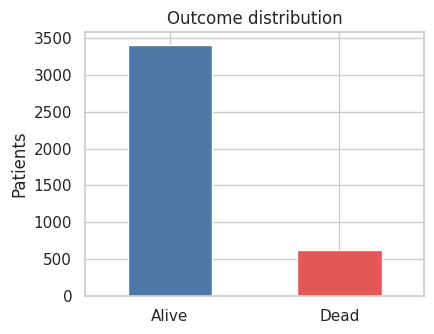

In [7]:
# --- Class balance -------------------------------------------------------------
counts = df["status"].value_counts()
prevalence = df["is_dead"].mean()
print(counts.to_string())
print(f"\nShare who died: {prevalence:.1%}  ->  always predicting 'Alive' would already be "
      f"{1 - prevalence:.1%} accurate, so accuracy alone is a weak yardstick here.")

ax = counts.plot(kind="bar", color=["#4C78A8", "#E45756"], figsize=(4.5, 3.5))
ax.set_title("Outcome distribution"); ax.set_ylabel("Patients"); ax.set_xlabel("")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

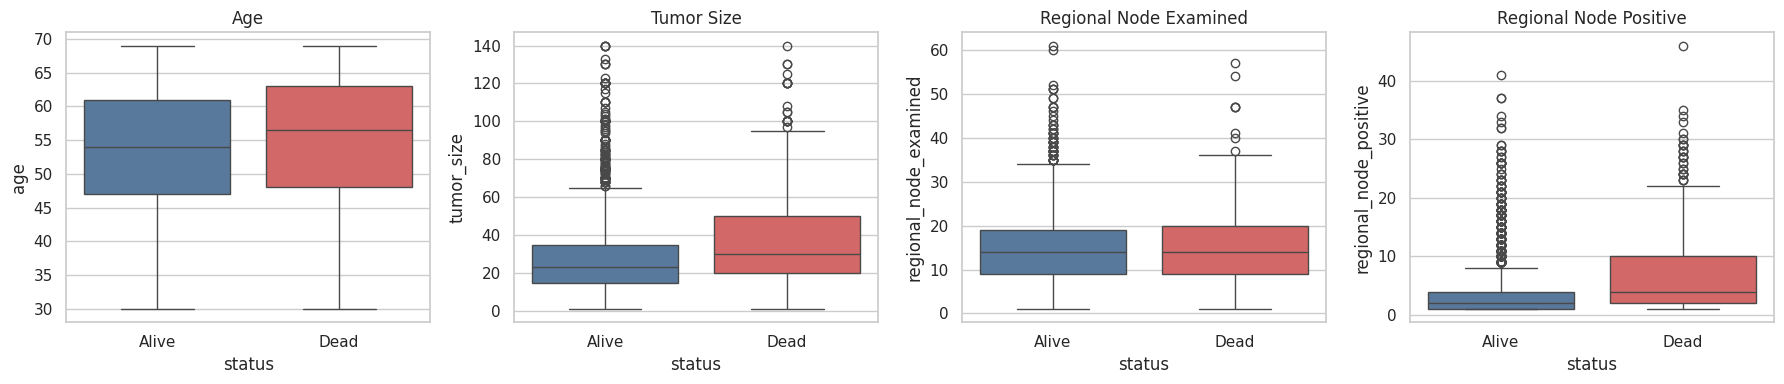

In [8]:
# --- Numeric features by outcome ----------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.boxplot(data=df, x="status", y=col, hue="status", order=["Alive", "Dead"],
                hue_order=["Alive", "Dead"], legend=False, ax=ax, palette=["#4C78A8", "#E45756"])
    ax.set_title(col.replace("_", " ").title())
plt.tight_layout(); plt.show()

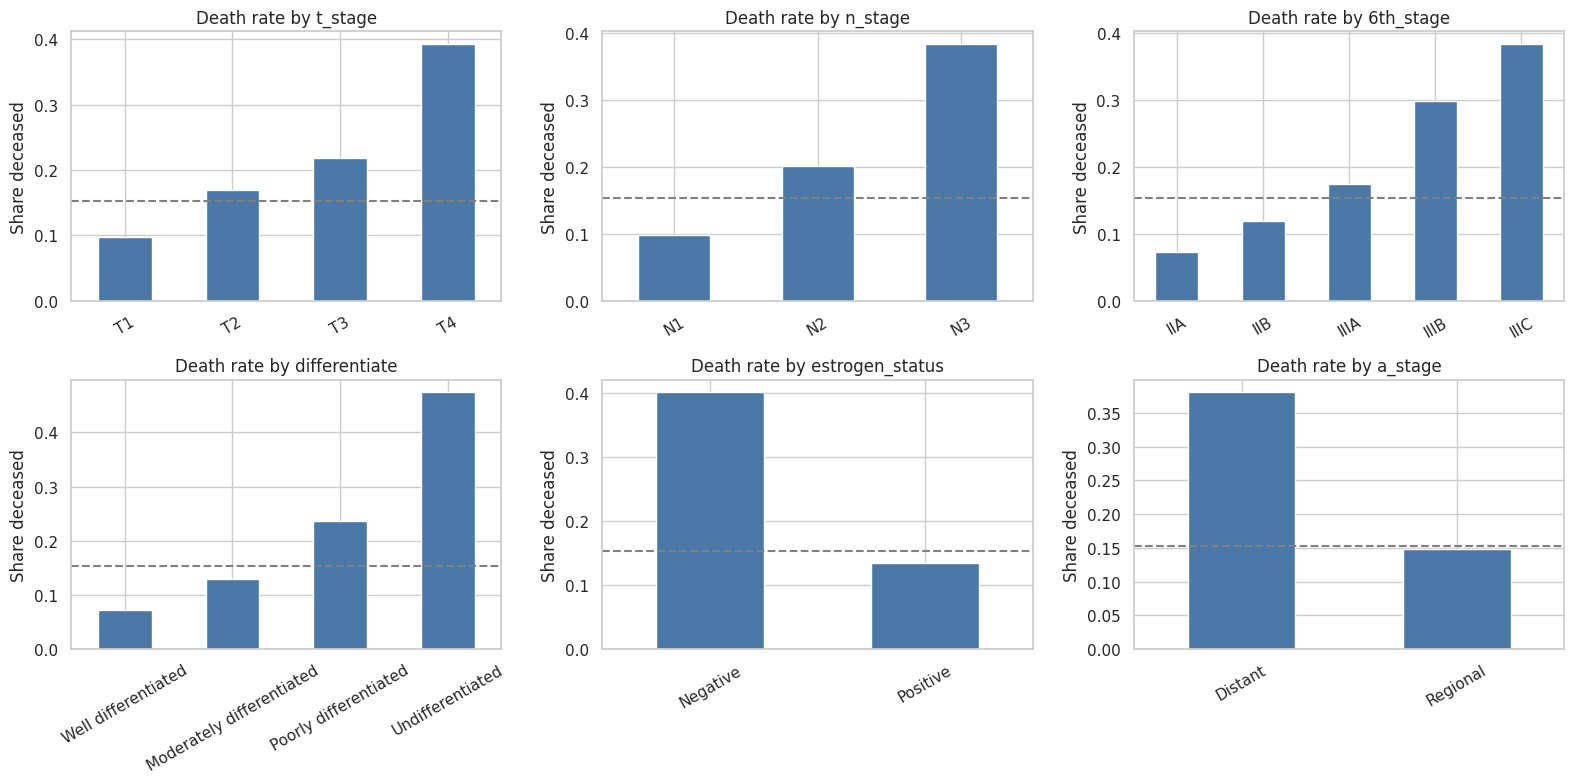

In [9]:
# --- Death rate by clinical category -------------------------------------------
# A bar far above the dashed line marks a group with worse-than-average outcomes.
rate_cols = ["t_stage", "n_stage", "6th_stage", "differentiate", "estrogen_status", "a_stage"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), rate_cols):
    rates = df.groupby(col)["is_dead"].mean()
    if col in ORDINAL_FEATURES:
        rates = rates.reindex(ORDINAL_FEATURES[col])
    rates.plot(kind="bar", ax=ax, color="#4C78A8")
    ax.axhline(prevalence, ls="--", color="gray")
    ax.set_title(f"Death rate by {col}"); ax.set_ylabel("Share deceased"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**What the plots show.** Death rates climb steadily as T stage, N stage, AJCC stage and tumor differentiation worsen, and are higher for estrogen-negative tumors and for distant-stage disease. That steady climb is the evidence for ordered encoding: the order of these categories carries real information that one-hot encoding would discard.

In [10]:
# --- Who is in the data? (context for the fairness audit later) ----------------
race_summary = df.groupby("race")["is_dead"].agg(patients="size", death_rate="mean")
race_summary["share_of_cohort"] = race_summary["patients"] / len(df)
display(race_summary)
print("Small groups give noisy performance estimates. Keep this in mind in Section 10.")

,patients,death_rate,share_of_cohort
race,,,
Black,291,0.251,0.072
Other,320,0.103,0.080
White,3413,0.149,0.848


Small groups give noisy performance estimates. Keep this in mind in Section 10.


## 5. Target definition and the leakage problem

`survival_months` records how long the patient was followed. Patients who died tend to have much shorter follow-up than patients who were still alive, so the column strongly signals the label. In a real setting it is **unknown at prediction time**, because it is only known after the outcome has happened. Any model that uses it looks great on paper and is useless in practice.

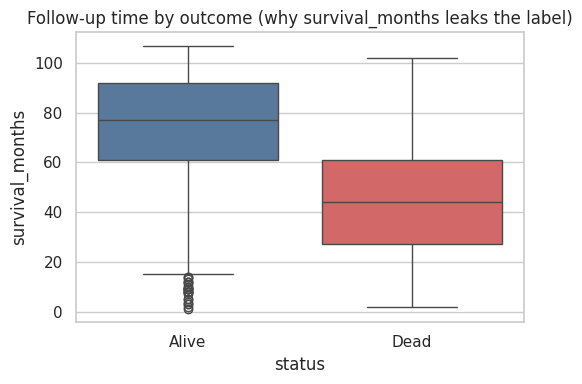

In [11]:
# The two boxes sit at very different heights, so follow-up time alone separates the outcomes well.
# The low 'Alive' outliers are patients with very short follow-up: a reminder of censoring (Section 2).
plt.figure(figsize=(5.5, 4))
sns.boxplot(data=df, x="status", y="survival_months", hue="status", order=["Alive", "Dead"],
            hue_order=["Alive", "Dead"], legend=False, palette=["#4C78A8", "#E45756"])
plt.title("Follow-up time by outcome (why survival_months leaks the label)")
plt.tight_layout(); plt.show()

## 6. Train/test split and preprocessing pipeline

The test set is set aside now and not touched again until the final evaluation. The split is **stratified** so both sets keep the same share of deaths.

In [12]:
# --- Features, target, and split -----------------------------------------------
X = df[FEATURES]                    # only the allowed inputs (no survival_months, no grade, no race by default)
y = df["is_dead"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {len(X_train):,} patients ({y_train.mean():.1%} deceased)")
print(f"Test : {len(X_test):,} patients ({y_test.mean():.1%} deceased)  <- held out until Section 9")

# Race is kept OUTSIDE the feature matrix so the model cannot use it, but we can audit by it later.
audit_info = df.loc[X_test.index, ["race", "marital_status", "age"]].copy()

Train: 3,219 patients (15.3% deceased)
Test : 805 patients (15.3% deceased)  <- held out until Section 9


In [13]:
# --- Preprocessing --------------------------------------------------------------
# Ordinal features -> integer codes that respect clinical order, then standardized.
# Binary/nominal features -> one-hot (drop='if_binary' avoids a redundant column for yes/no style fields).
# Numeric features -> standardized (needed by logistic regression; harmless for tree models).
# handle_unknown='ignore' means a category unseen in training will not crash the app.
def build_preprocessor(numeric_features=NUMERIC_FEATURES):
    ordinal_pipe = Pipeline([
        ("encode", OrdinalEncoder(categories=list(ORDINAL_FEATURES.values()))),
        ("scale", StandardScaler()),
    ])
    return ColumnTransformer([
        ("ordinal", ordinal_pipe, list(ORDINAL_FEATURES)),
        ("categorical", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
         CATEGORICAL_FEATURES),
        ("numeric", StandardScaler(), list(numeric_features)),
    ])

def make_model_pipeline(estimator, numeric_features=NUMERIC_FEATURES):
    # Preprocessing lives inside the pipeline so cross-validation re-fits it on each training fold.
    return Pipeline([("prep", build_preprocessor(numeric_features)), ("clf", estimator)])

# Stratified 5-fold CV used for every comparison below.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### Leakage demonstration (for the report only)

To show *why* `survival_months` had to go, we compare cross-validated ROC-AUC with and without it. The version that includes it is **not** a valid model. It is shown only to quantify how misleading the leaky number would be.

In [14]:
# Same model, same folds: the only difference is whether survival_months is available.
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

X_train_leaky = X_train.assign(survival_months=df.loc[X_train.index, "survival_months"])
auc_clean = cross_val_score(make_model_pipeline(gb), X_train, y_train, cv=cv, scoring="roc_auc").mean()
auc_leaky = cross_val_score(make_model_pipeline(gb, NUMERIC_FEATURES + ["survival_months"]),
                            X_train_leaky, y_train, cv=cv, scoring="roc_auc").mean()

print(f"ROC-AUC WITHOUT survival_months (valid)  : {auc_clean:.3f}")
print(f"ROC-AUC WITH    survival_months (leaky)  : {auc_leaky:.3f}")
print("The jump comes from information that would not exist at prediction time.")

ROC-AUC WITHOUT survival_months (valid)  : 0.727
ROC-AUC WITH    survival_months (leaky)  : 0.868
The jump comes from information that would not exist at prediction time.


## 7. Model comparison with cross-validation

We compare a do-nothing **baseline**, logistic regression, random forest, and gradient boosting using 5-fold cross-validation on the **training set only**.

* **PR-AUC** (average precision) is the headline metric because the positive class is rare; a random model scores about the prevalence.
* **ROC-AUC** measures ranking ability across all thresholds.
* Recall, precision and F1 at the default 0.5 cutoff are shown for reference. They will look weak because 0.5 is the wrong cutoff for a rare outcome, which is addressed in Section 8.
* Class weighting is deliberately **not** used: reweighting distorts predicted probabilities. Imbalance is handled by choosing the threshold instead, which keeps the probabilities interpretable.

In [15]:
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

candidates = {
    "Baseline (predict prior)": DummyClassifier(strategy="prior"),
    "Logistic regression": LogisticRegression(max_iter=2000),
    "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Gradient boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv_mean, cv_std = {}, {}
for name, estimator in candidates.items():
    scores = cross_validate(make_model_pipeline(estimator), X_train, y_train,
                            cv=cv, scoring=scoring, n_jobs=-1)
    cv_mean[name] = {m: scores[f"test_{m}"].mean() for m in scoring}
    cv_std[name] = {m: scores[f"test_{m}"].std() for m in scoring}

cv_mean = pd.DataFrame(cv_mean).T
cv_std = pd.DataFrame(cv_std).T

# Show "mean ± std" so the spread across folds is visible (a 0.01 gap is usually just noise).
display((cv_mean.round(3).astype(str) + " ± " + cv_std.round(3).astype(str))
        .sort_values("pr_auc", ascending=False))

,roc_auc,pr_auc,recall,precision,f1
Logistic regression,0.747 ± 0.034,0.412 ± 0.029,0.158 ± 0.021,0.632 ± 0.052,0.252 ± 0.025
Random forest,0.725 ± 0.022,0.386 ± 0.022,0.122 ± 0.029,0.637 ± 0.069,0.202 ± 0.04
Gradient boosting,0.727 ± 0.024,0.385 ± 0.033,0.179 ± 0.027,0.55 ± 0.054,0.268 ± 0.032
Baseline (predict prior),0.5 ± 0.0,0.153 ± 0.001,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0


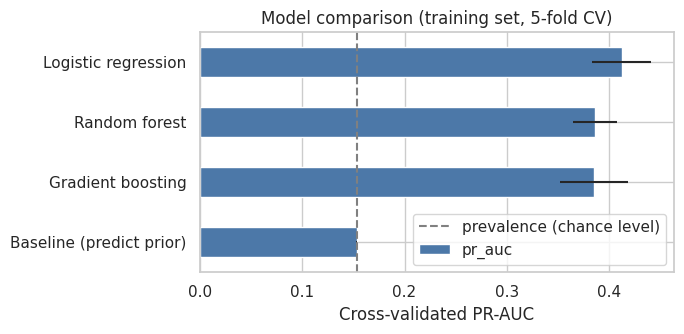

In [16]:
# Visual comparison of PR-AUC; the dashed line is what a useless model would score.
ax = cv_mean["pr_auc"].sort_values().plot(kind="barh", xerr=cv_std["pr_auc"].reindex(
    cv_mean["pr_auc"].sort_values().index), figsize=(7, 3.5), color="#4C78A8")
ax.axvline(y_train.mean(), ls="--", color="gray", label="prevalence (chance level)")
ax.set_xlabel("Cross-validated PR-AUC"); ax.set_title("Model comparison (training set, 5-fold CV)")
ax.legend(); plt.tight_layout(); plt.show()

### Light hyperparameter tuning

Gradient boosting has several settings that matter. We use a small randomized search, scored on PR-AUC with the same folds. The search stays inside the training data.

In [17]:
param_distributions = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.02, 0.05, 0.1],
    "clf__max_depth": [2, 3, 4],
    "clf__subsample": [0.7, 0.85, 1.0],
    "clf__min_samples_leaf": [5, 10, 20],
}

search = RandomizedSearchCV(
    make_model_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    param_distributions=param_distributions,
    n_iter=12, scoring="average_precision", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True)
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print(f"Best cross-validated PR-AUC: {search.best_score_:.3f}")

Best parameters: {'clf__subsample': 0.7, 'clf__n_estimators': 300, 'clf__min_samples_leaf': 20, 'clf__max_depth': 2, 'clf__learning_rate': 0.02}
Best cross-validated PR-AUC: 0.409


In [18]:
# --- Pick the final model using CROSS-VALIDATION scores only -------------------
# We keep the simplest strong option (logistic regression) versus the tuned booster.
# search.best_score_ is slightly optimistic because it was picked as the best of many tries,
# so a tie or near-tie should favor the simpler, more interpretable model.
final_candidates = {
    "Logistic regression": (cv_mean.loc["Logistic regression", "pr_auc"],
                            make_model_pipeline(LogisticRegression(max_iter=2000))),
    "Gradient boosting (tuned)": (search.best_score_, search.best_estimator_),
}
score_lr = final_candidates["Logistic regression"][0]
score_gb = final_candidates["Gradient boosting (tuned)"][0]
MARGIN = 0.01   # boosting must beat logistic regression by at least this much PR-AUC to be chosen
final_name = "Gradient boosting (tuned)" if score_gb > score_lr + MARGIN else "Logistic regression"
final_model = clone(final_candidates[final_name][1])

print(f"CV PR-AUC  logistic regression: {score_lr:.3f} | tuned gradient boosting: {score_gb:.3f}")
print(f"Selected model: {final_name}")

CV PR-AUC  logistic regression: 0.412 | tuned gradient boosting: 0.409
Selected model: Logistic regression


## 8. Choosing the decision threshold

A model outputs a probability. Turning that into a "flag this patient" decision needs a threshold. Here the goal is set by a clinical-style requirement: **catch at least `TARGET_RECALL` of the patients who died**, accepting more false alarms in exchange.

To avoid peeking at the test set, the threshold is picked from **out-of-fold predictions on the training data**: each training patient is scored by a model that never saw that patient.

Chosen threshold: 0.098
Out-of-fold recall: 0.801 | precision: 0.234 | share of patients flagged: 52.5%


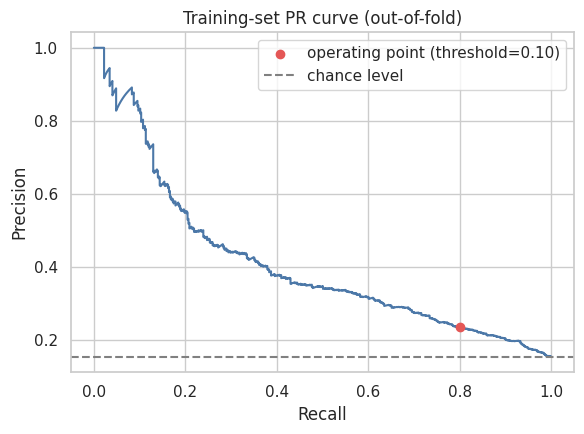

In [19]:
# Out-of-fold probabilities on the training set (each row predicted by a model that did not train on it).
oof_prob = cross_val_predict(clone(final_model), X_train, y_train, cv=cv, method="predict_proba")[:, 1]

precision_c, recall_c, thresholds = precision_recall_curve(y_train, oof_prob)

# precision/recall arrays have one more entry than thresholds; drop the last point to align them.
# Among thresholds that reach the target recall, take the HIGHEST one (fewest false alarms).
meets_target = recall_c[:-1] >= TARGET_RECALL
if meets_target.any():
    threshold = float(thresholds[meets_target].max())
else:
    threshold = 0.5
    print("Target recall not reachable; falling back to 0.5")

oof_pred = (oof_prob >= threshold).astype(int)
print(f"Chosen threshold: {threshold:.3f}")
print(f"Out-of-fold recall: {recall_score(y_train, oof_pred):.3f} | "
      f"precision: {precision_score(y_train, oof_pred, zero_division=0):.3f} | "
      f"share of patients flagged: {oof_pred.mean():.1%}")

plt.figure(figsize=(6, 4.5))
plt.plot(recall_c, precision_c, color="#4C78A8")
plt.scatter([recall_score(y_train, oof_pred)], [precision_score(y_train, oof_pred, zero_division=0)],
            color="#E45756", zorder=3, label=f"operating point (threshold={threshold:.2f})")
plt.axhline(y_train.mean(), ls="--", color="gray", label="chance level")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Training-set PR curve (out-of-fold)")
plt.legend(); plt.tight_layout(); plt.show()

## 9. Final evaluation on the held-out test set (one time)

The model is now trained on the full training set and evaluated once on patients it has never seen. Two operating points are compared: the default 0.5 cutoff and the threshold chosen in Section 8.

In [20]:
final_model.fit(X_train, y_train)
prob_test = final_model.predict_proba(X_test)[:, 1]

def evaluate(y_true, prob, thr):
    """Return the metrics that matter for a screening-style model at a given threshold."""
    pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": thr,
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "recall (sensitivity)": tp / (tp + fn) if (tp + fn) else 0.0,
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "precision": tp / (tp + fp) if (tp + fp) else 0.0,
        "f1": f1_score(y_true, pred, zero_division=0),
        "share flagged": pred.mean(),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }

test_auc = roc_auc_score(y_test, prob_test)
test_pr_auc = average_precision_score(y_test, prob_test)
test_brier = brier_score_loss(y_test, prob_test)

results = pd.DataFrame({
    "Always predict 'Alive'": evaluate(y_test, np.zeros(len(y_test)), 0.5),
    "Model @ default 0.5": evaluate(y_test, prob_test, 0.5),
    f"Model @ chosen {threshold:.2f}": evaluate(y_test, prob_test, threshold),
}).T
results[["TP", "FP", "FN", "TN"]] = results[["TP", "FP", "FN", "TN"]].astype(int)  # counts read better as integers
display(results)

print(f"\nThreshold-free metrics: ROC-AUC = {test_auc:.3f} | PR-AUC = {test_pr_auc:.3f} "
      f"(chance = {y_test.mean():.3f}) | Brier score = {test_brier:.3f}")

,threshold,accuracy,recall (sensitivity),specificity,precision,f1,share flagged,TP,FP,FN,TN
Always predict 'Alive',0.500,0.847,0.000,1.000,0.000,0.000,0.000,0,0,123,682
Model @ default 0.5,0.500,0.852,0.138,0.981,0.567,0.222,0.037,17,13,106,669
Model @ chosen 0.10,0.098,0.552,0.789,0.509,0.225,0.350,0.537,97,335,26,347



Threshold-free metrics: ROC-AUC = 0.718 | PR-AUC = 0.366 (chance = 0.153) | Brier score = 0.116


In [21]:
# --- Uncertainty: the test set is small, so report bootstrap confidence intervals ---
rng = np.random.default_rng(RANDOM_STATE)
y_arr = y_test.to_numpy()
boot_auc, boot_pr, boot_recall = [], [], []
for _ in range(1000):
    idx = rng.integers(0, len(y_arr), len(y_arr))          # resample patients with replacement
    yt, pp = y_arr[idx], prob_test[idx]
    if yt.min() == yt.max():                               # need both classes to score
        continue
    boot_auc.append(roc_auc_score(yt, pp))
    boot_pr.append(average_precision_score(yt, pp))
    boot_recall.append(recall_score(yt, (pp >= threshold).astype(int), zero_division=0))

def ci(values):
    lo, hi = np.percentile(values, [2.5, 97.5])
    return f"{np.mean(values):.3f} (95% CI {lo:.3f} to {hi:.3f})"

print("ROC-AUC :", ci(boot_auc))
print("PR-AUC  :", ci(boot_pr))
print(f"Recall @ {threshold:.2f}:", ci(boot_recall))

ROC-AUC : 0.718 (95% CI 0.667 to 0.768)
PR-AUC  : 0.375 (95% CI 0.294 to 0.469)
Recall @ 0.10: 0.789 (95% CI 0.716 to 0.857)


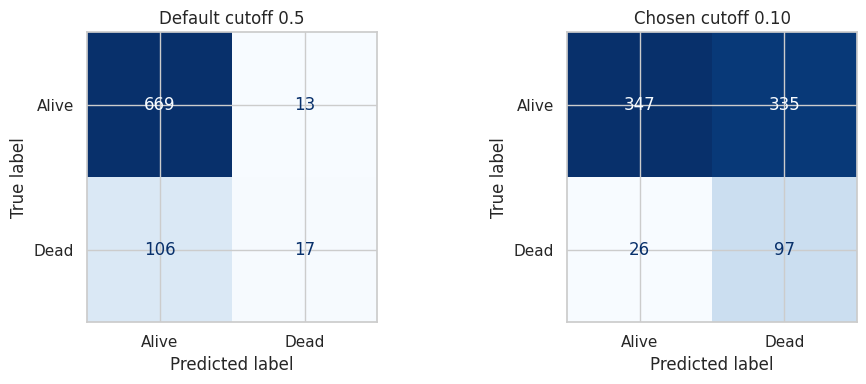

Rows = actual, columns = predicted. Bottom-left cell = missed deaths (false negatives).


In [22]:
# --- Confusion matrices at both operating points ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, thr, title in zip(axes, [0.5, threshold], ["Default cutoff 0.5", f"Chosen cutoff {threshold:.2f}"]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, (prob_test >= thr).astype(int), display_labels=["Alive", "Dead"],
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
plt.tight_layout(); plt.show()
print("Rows = actual, columns = predicted. Bottom-left cell = missed deaths (false negatives).")

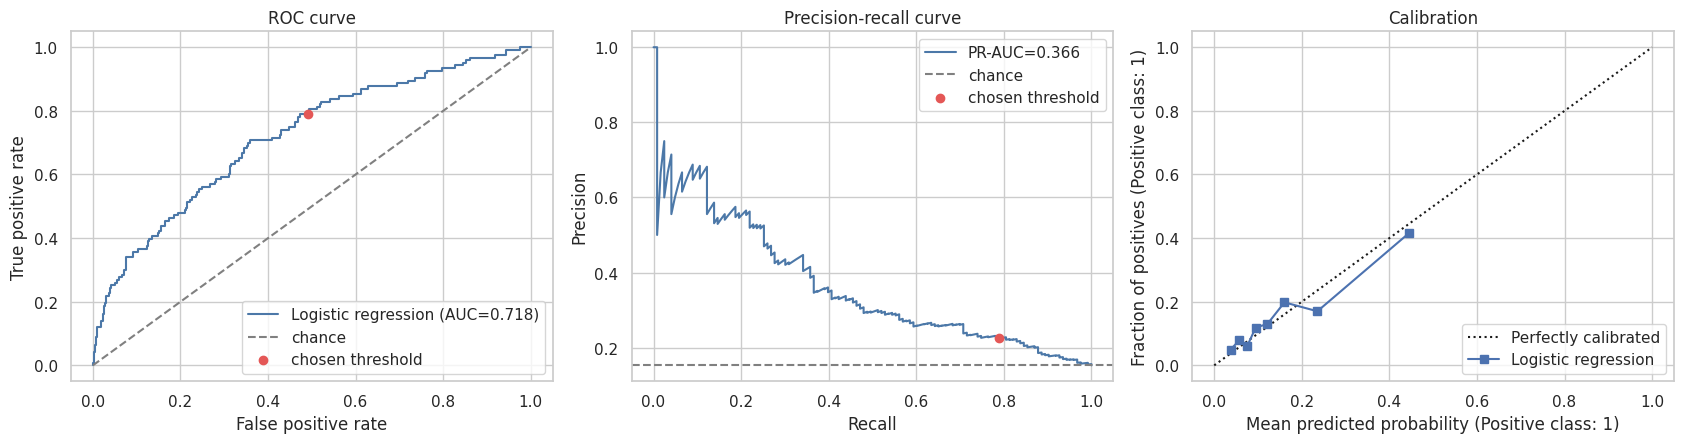

In [23]:
# --- ROC, precision-recall, and calibration curves ----------------------------
chosen = evaluate(y_test, prob_test, threshold)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

fpr, tpr, _ = roc_curve(y_test, prob_test)
axes[0].plot(fpr, tpr, label=f"{final_name} (AUC={test_auc:.3f})", color="#4C78A8")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="chance")
axes[0].scatter([1 - chosen["specificity"]], [chosen["recall (sensitivity)"]], color="#E45756", zorder=3,
                label="chosen threshold")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve"); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, prob_test)
axes[1].plot(rec, prec, color="#4C78A8", label=f"PR-AUC={test_pr_auc:.3f}")
axes[1].axhline(y_test.mean(), ls="--", color="gray", label="chance")
axes[1].scatter([chosen["recall (sensitivity)"]], [chosen["precision"]], color="#E45756", zorder=3,
                label="chosen threshold")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve"); axes[1].legend()

# Calibration: do predicted probabilities match observed death rates? Points on the diagonal = well calibrated.
CalibrationDisplay.from_predictions(y_test, prob_test, n_bins=8, strategy="quantile", ax=axes[2], name=final_name)
axes[2].set_title("Calibration")
plt.tight_layout(); plt.show()

**Reading the results.** At the default 0.5 cutoff the model looks accurate mainly because it almost never predicts a death, so it barely beats the always-'Alive' baseline on accuracy while missing most deaths. The threshold-free metrics show real but modest signal: ROC-AUC is clearly above chance and PR-AUC is more than double the chance level. Reaching the recall target means flagging roughly half of all patients, and only about one in five flagged patients actually died. In the calibration panel, predicted probabilities track observed rates well at the low end, where most patients sit, with less certainty in the sparse high-risk bins.

### Which features drive the predictions?

Permutation importance measures how much the score drops when one feature's values are shuffled on the **held-out** data. It works on the original, human-readable columns and is less biased than the built-in importances of tree models.

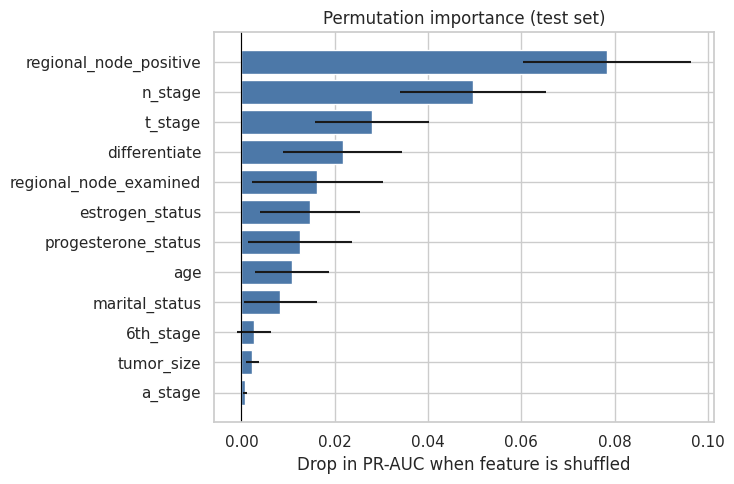

,feature,mean,std
11,regional_node_positive,0.078,0.018
1,n_stage,0.050,0.016
0,t_stage,0.028,0.012
3,differentiate,0.022,0.013
10,regional_node_examined,0.016,0.014


In [24]:
perm = permutation_importance(final_model, X_test, y_test, scoring="average_precision",
                              n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.DataFrame({"feature": FEATURES, "mean": perm.importances_mean, "std": perm.importances_std})
              .sort_values("mean", ascending=True))

plt.figure(figsize=(7.5, 5))
plt.barh(importance["feature"], importance["mean"], xerr=importance["std"], color="#4C78A8")
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Drop in PR-AUC when feature is shuffled"); plt.title("Permutation importance (test set)")
plt.tight_layout(); plt.show()
display(importance.sort_values("mean", ascending=False).head(5))

**Reading the importance plot.** Lymph node involvement (positive node count and N stage) leads, followed by tumor stage and differentiation. This agrees with established clinical understanding that nodal status is among the strongest prognostic factors, which is a useful sanity check: the model learned clinically plausible signal rather than an artifact.

## 10. Fairness and subgroup audit

An overall score can hide groups the model serves poorly, a lesson from published studies of healthcare algorithms. Here performance is broken out by race and by age band at the chosen threshold.

**Read this table carefully:** subgroups with few deaths give very noisy recall and AUC, so those rows are flagged. A large gap is a reason to investigate, and a small gap in a tiny group is not evidence of fairness.

In [25]:
audit = audit_info.copy()
audit["y"] = y_test.to_numpy()
audit["prob"] = prob_test
audit["flag"] = (prob_test >= threshold).astype(int)
audit["age_group"] = pd.cut(audit["age"], bins=[0, 49, 64, 120], labels=["<50", "50-64", "65+"])

def subgroup_table(column):
    rows = []
    for group, g in audit.groupby(column, observed=True):
        deaths = int(g["y"].sum())
        rows.append({
            column: group,
            "patients": len(g),
            "deaths": deaths,
            "death rate": g["y"].mean(),
            "flagged": g["flag"].mean(),
            # Recall needs at least one death; ROC-AUC needs both outcomes present.
            "recall": g.loc[g["y"] == 1, "flag"].mean() if deaths else np.nan,
            "precision": g.loc[g["flag"] == 1, "y"].mean() if g["flag"].sum() else np.nan,
            "ROC-AUC": roc_auc_score(g["y"], g["prob"]) if 0 < deaths < len(g) else np.nan,
            "note": "few deaths: unreliable" if deaths < 20 else "",
        })
    return pd.DataFrame(rows).set_index(column)

for col in ["race", "age_group", "marital_status"]:
    print(f"\nPerformance by {col}")
    display(subgroup_table(col))


Performance by race


,patients,deaths,death rate,flagged,recall,precision,ROC-AUC,note
race,,,,,,,,
Black,69,17,0.246,0.652,0.882,0.333,0.722,few deaths: unreliable
Other,62,6,0.097,0.532,0.833,0.152,0.735,few deaths: unreliable
White,674,100,0.148,0.525,0.770,0.218,0.713,



Performance by age_group


,patients,deaths,death rate,flagged,recall,precision,ROC-AUC,note
age_group,,,,,,,,
<50,264,33,0.125,0.424,0.727,0.214,0.773,
50-64,422,62,0.147,0.564,0.774,0.202,0.684,
65+,119,28,0.235,0.689,0.893,0.305,0.692,



Performance by marital_status


,patients,deaths,death rate,flagged,recall,precision,ROC-AUC,note
marital_status,,,,,,,,
Divorced,98,18,0.184,0.673,0.833,0.227,0.694,few deaths: unreliable
Married,519,75,0.145,0.451,0.760,0.244,0.729,
Separated,9,3,0.333,0.889,1.000,0.375,0.722,few deaths: unreliable
Single,119,18,0.151,0.655,0.778,0.179,0.693,few deaths: unreliable
Widowed,60,9,0.150,0.767,0.889,0.174,0.712,few deaths: unreliable


**Reading the audit.** Recall is in a broadly similar range across groups, but most subgroups contain few deaths, so the differences between them are not statistically reliable (rows are flagged accordingly). Two things stand out. First, the cohort is about 85% White, so groups such as "Other" contain very few deaths and cannot support any conclusion. Second, the observed death rate differs by race in this cohort and the model flags Black patients more often. That is consistent with higher observed mortality, but it could also reflect proxies for unequal access to care (for example stage at diagnosis) rather than biology. An audit like this can raise concerns; it cannot settle them, and a larger, more representative dataset would be needed to make claims about fairness.

## 11. The application: saving the model and scoring a new patient

Now the trained pipeline is packaged as a small application. The model and its metadata (allowed categories, numeric ranges, threshold, test metrics) are saved to `models/`, then wrapped in a `predict_risk()` function that validates the input and returns a probability, a flag, and a plain-language message. The same artifacts power the Streamlit app in `app.py`.

In [26]:
# --- Save the trained pipeline and everything the app needs to use it safely ---
MODEL_PATH = MODEL_DIR / "risk_model.joblib"
META_PATH = MODEL_DIR / "model_meta.json"

joblib.dump(final_model, MODEL_PATH)

meta = {
    "model_name": final_name,
    "created": str(date.today()),
    "sklearn_version": sklearn.__version__,
    "data_source": data_source,
    "threshold": float(threshold),
    "target_recall": TARGET_RECALL,
    "features": FEATURES,
    "ordinal_categories": ORDINAL_FEATURES,
    "categorical_options": {c: sorted(df[c].unique().tolist()) for c in CATEGORICAL_FEATURES},
    "numeric_ranges": {c: {"min": float(df[c].min()), "max": float(df[c].max()),
                           "median": float(df[c].median())} for c in NUMERIC_FEATURES},
    "test_metrics": {
        "roc_auc": float(test_auc),
        "pr_auc": float(test_pr_auc),
        "brier": float(test_brier),
        "recall_at_threshold": float(chosen["recall (sensitivity)"]),
        "precision_at_threshold": float(chosen["precision"]),
        "prevalence_test": float(y_test.mean()),
    },
}
META_PATH.write_text(json.dumps(meta, indent=2))
print(f"Saved {MODEL_PATH} and {META_PATH}")

Saved models/risk_model.joblib and models/model_meta.json


In [27]:
def predict_risk(patient, model=None, meta_info=None):
    """Score one patient dictionary and return a probability, a flag, and a readable message.

    The function checks every field before scoring so a typo produces a clear error
    instead of a silently wrong prediction.
    """
    model = joblib.load(MODEL_PATH) if model is None else model
    meta_info = json.loads(META_PATH.read_text()) if meta_info is None else meta_info

    missing = [f for f in meta_info["features"] if f not in patient]
    if missing:
        raise ValueError(f"Missing fields: {missing}")
    if patient["regional_node_positive"] > patient["regional_node_examined"]:
        raise ValueError("Positive lymph nodes cannot exceed the number of nodes examined.")

    for col, order in meta_info["ordinal_categories"].items():
        if patient[col] not in order:
            raise ValueError(f"{col} must be one of {order}, got {patient[col]!r}")
    for col, options in meta_info["categorical_options"].items():
        if patient[col] not in options:
            raise ValueError(f"{col} must be one of {options}, got {patient[col]!r}")
    for col, rng_ in meta_info["numeric_ranges"].items():
        if not rng_["min"] <= patient[col] <= rng_["max"]:
            raise ValueError(f"{col}={patient[col]} is outside the range seen in training "
                             f"({rng_['min']:.0f} to {rng_['max']:.0f}); the model cannot be trusted here.")

    row = pd.DataFrame([patient])[meta_info["features"]]        # column order must match training
    probability = float(model.predict_proba(row)[0, 1])
    flagged = probability >= meta_info["threshold"]
    return {
        "probability": probability,
        "flagged_higher_risk": bool(flagged),
        "threshold": meta_info["threshold"],
        "message": ("Higher-risk profile: similar registry patients had worse outcomes; "
                    "would warrant closer clinical review." if flagged else
                    "Lower-risk profile relative to the screening threshold."),
        "disclaimer": "Educational demo built on 2006-2010 registry data. Not medical advice.",
    }

In [28]:
# --- Two illustrative patients (fictional) --------------------------------------
patient_lower = {
    "age": 52, "tumor_size": 14, "t_stage": "T1", "n_stage": "N1", "6th_stage": "IIA",
    "differentiate": "Well differentiated", "a_stage": "Regional",
    "estrogen_status": "Positive", "progesterone_status": "Positive",
    "regional_node_examined": 12, "regional_node_positive": 1, "marital_status": "Married",
}
patient_higher = {
    "age": 66, "tumor_size": 62, "t_stage": "T3", "n_stage": "N3", "6th_stage": "IIIC",
    "differentiate": "Poorly differentiated", "a_stage": "Distant",
    "estrogen_status": "Negative", "progesterone_status": "Negative",
    "regional_node_examined": 20, "regional_node_positive": 16, "marital_status": "Widowed",
}
for label, p in [("Patient A", patient_lower), ("Patient B", patient_higher)]:
    r = predict_risk(p, model=final_model, meta_info=meta)
    print(f"{label}: estimated probability {r['probability']:.1%} | flagged: {r['flagged_higher_risk']}")
    print("   ", r["message"])

# Input validation in action (should raise a clear error):
try:
    predict_risk({**patient_lower, "t_stage": "T9"}, model=final_model, meta_info=meta)
except ValueError as err:
    print("\nValidation works ->", err)

Patient A: estimated probability 3.1% | flagged: False
    Lower-risk profile relative to the screening threshold.
Patient B: estimated probability 86.8% | flagged: True
    Higher-risk profile: similar registry patients had worse outcomes; would warrant closer clinical review.

Validation works -> t_stage must be one of ['T1', 'T2', 'T3', 'T4'], got 'T9'


### Running the interactive app

From the repository folder, after running this notebook once so `models/` exists:

```bash
pip install -r requirements.txt
streamlit run app.py
```

The app builds its input form from `models/model_meta.json`, so it always matches the trained model.

In [29]:
# --- Auto-generated results summary (numbers come from this run, nothing is hard-coded) ---
summary = f"""
### Results summary

* **Selected model:** {final_name} (chosen by cross-validated PR-AUC on the training set).
* **Test-set ranking quality:** ROC-AUC {test_auc:.3f}, PR-AUC {test_pr_auc:.3f} versus a chance level of {y_test.mean():.3f}.
* **At the chosen threshold ({threshold:.2f}):** recall {chosen['recall (sensitivity)']:.1%}, precision {chosen['precision']:.1%}, flagging {chosen['share flagged']:.1%} of patients. {int(chosen['FN'])} of {int(y_test.sum())} deaths in the test set were missed.
* **Versus the naive baseline:** always predicting 'Alive' scores {1 - y_test.mean():.1%} accuracy but catches 0% of deaths.
* **Leakage check:** including survival_months would have inflated cross-validated ROC-AUC from {auc_clean:.3f} to {auc_leaky:.3f}.
"""
display(Markdown(summary))


### Results summary

* **Selected model:** Logistic regression (chosen by cross-validated PR-AUC on the training set).
* **Test-set ranking quality:** ROC-AUC 0.718, PR-AUC 0.366 versus a chance level of 0.153.
* **At the chosen threshold (0.10):** recall 78.9%, precision 22.5%, flagging 53.7% of patients. 26 of 123 deaths in the test set were missed.
* **Versus the naive baseline:** always predicting 'Alive' scores 84.7% accuracy but catches 0% of deaths.
* **Leakage check:** including survival_months would have inflated cross-validated ROC-AUC from 0.727 to 0.868.


## 12. Limitations, ethics, and responsible use

**Data and label**

* The data is from 2006-2010 diagnoses. Treatments and outcomes have changed, so the model reflects historical practice and would need re-validation before any modern use.
* The label is vital status at the end of follow-up (all-cause), not five-year breast-cancer-specific survival. Censoring is not modeled; a survival-analysis approach (for example Kaplan-Meier or Cox models) would be more appropriate for a serious study.
* The cohort is limited to two tumor types and excludes patients with unknown tumor size or node counts, so results may not carry over to other patients.
* The training data covers a limited age band (see the numeric summary in Section 3), so `predict_risk()` refuses inputs outside the ranges seen in training rather than extrapolating.

**Model performance**

* Even after fixing leakage and tuning the threshold, the model trades recall against many false alarms. The confusion matrices and bootstrap intervals show the uncertainty. A single split of about 800 test patients with limited deaths gives wide intervals.
* This is a single retrospective dataset with no external validation. Real tools such as Clairity Breast were validated across many sites before authorization.

**Bias and fairness**

* Group sizes are unequal (see Sections 4 and 10). Race is excluded as an input, but that alone does not guarantee fairness: other features can act as proxies (for example marital status, or stage at diagnosis, which reflects access to screening).
* Health-algorithm research (Obermeyer et al., 2019) shows that a model can look accurate overall while systematically under-serving a group, especially if the label reflects unequal access to care.

**Responsible use**

* This model must **not** be used to make or delay care decisions, to ration resources, or to counsel patients about prognosis. It is a learning artifact.
* If it ever handled live patient data, it would need consent, de-identification, secure storage and audit logging (HIPAA-style safeguards), clinical validation, and regulatory review, the same path Clairity Breast went through.
* Predictions should support, not replace, a clinician's judgment, and the interface should always show uncertainty and a disclaimer, as the app does.

## 13. References

**Innovation research (Clairity Breast)**

1. Breast Cancer Research Foundation. "A Breakthrough in Breast Cancer Prevention: FDA Clears First AI Tool to Predict Risk Using a Mammogram." June 2, 2025. https://www.bcrf.org/blog/clairity-breast-ai-artificial-intelligence-mammogram-approved/
2. MedTech Dive. "Clairity receives FDA OK for breast cancer risk prediction tool." June 3, 2025. https://www.medtechdive.com/news/clairity-de-novo-ai-breast-cancer-risk-prediction/749697/
3. AuntMinnie. "Clairity deploys AI for breast cancer risk prediction." June 2025. https://www.auntminnie.com/imaging-informatics/artificial-intelligence/article/15747944/clairity-deploys-ai-for-breast-cancer-risk-prediction
4. Cancer Therapy Advisor (HealthDay). "FDA Authorizes First AI Platform for Breast Cancer Prediction." June 9, 2025. https://www.cancertherapyadvisor.com/news/fda-authorizes-first-ai-platform-for-breast-cancer-prediction/
5. Clairity, Inc. "First Patient Receives FDA-Authorized Clairity Breast Score." GlobeNewswire, Feb 23, 2026. https://www.globenewswire.com/news-release/2026/02/23/3242566/0/en/First-Patient-Receives-FDA-Authorized-Clairity-Breast-Score-Marking-a-New-Era-in-AI-Empowered-Breast-Cancer-Risk-Assessment.html
6. American Association for Cancer Research. "AI Breast Cancer Prediction Tool Hits the Clinic." *Cancer Discovery*, April 2026. https://aacrjournals.org/cancerdiscovery/article/doi/10.1158/2159-8290.CD-NW2026-0037/782681/AI-Breast-Cancer-Prediction-Tool-Hits-the-ClinicAI
7. OncLive. "Clairity Breast Is Added to NCCN Guidelines for Breast Cancer Screening and Diagnosis." August 2026. https://www.onclive.com/view/clairity-breast-is-added-to-nccn-guidelines-for-breast-cancer-screening-and-diagnosis
8. Clairity, Inc. Company website and RSNA 2025 page (company-reported figures). https://clairity.com/

**Related peer-reviewed work**

9. McKinney, S. M., et al. "International evaluation of an AI system for breast cancer screening." *Nature* 577, 89-94 (2020).
10. Yala, A., et al. "Toward robust mammography-based models for breast cancer risk." *Science Translational Medicine* (2021).
11. Obermeyer, Z., Powers, B., Vogeli, C., & Mullainathan, S. "Dissecting racial bias in an algorithm used to manage the health of populations." *Science* 366(6464), 447-453 (2019).

**Data and tools**

12. Namdari, R. "Breast Cancer" (SEER, November 2017 update). Kaggle. https://www.kaggle.com/datasets/reihanenamdari/breast-cancer. Original source: National Cancer Institute SEER Program.
13. Pedregosa, F., et al. "Scikit-learn: Machine Learning in Python." *JMLR* 12, 2825-2830 (2011).